## **Importação das bibliotecas e datasets e criação das funções**

In [1]:
import json
import os
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.initializers import GlorotUniform, Orthogonal
from keras.layers import Dense,Dropout,SimpleRNN,LSTM #Biblioteca para deep learning
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Configurar a seed para o Python, NumPy e TensorFlow
SEED = 42  # valor fixo que será utilizado como seed

# Seed para o Python
random.seed(SEED)

# Seed para o NumPy (usado para operações de matriz e aleatoriedade fora do TensorFlow)
np.random.seed(SEED)

# Seed para o TensorFlow
tf.random.set_seed(SEED)

In [2]:
base_path = './dataset/'
time_base = 'days'
agrupamento = "3"
dataset_type = f"{agrupamento}_days_dataset"

In [3]:
# Carregar o arquivo JSON
with open('config_pso.json') as f:
    config = json.load(f)

In [4]:
# Cria um diretório específico se não existir
diretorio_pesos_teste_1 = "pesos/teste_1"
os.makedirs(diretorio_pesos_teste_1, exist_ok=True)

diretorio_pesos_teste_3 = "pesos/teste_3"
os.makedirs(diretorio_pesos_teste_3, exist_ok=True)

In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))  # Padronização dos dados

duas_unas_dataset = f'{base_path}duas_unas/{time_base}/grouped_{agrupamento}_{time_base}.csv'
prataI_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_I_{agrupamento}_{time_base}.csv'
prataII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_II_{agrupamento}_{time_base}.csv'
prataIII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_III_{agrupamento}_{time_base}.csv'
pirapama_dataset = f'{base_path}outras_unidades/pirapama/Pirapama_{agrupamento}_{time_base}.csv'

In [6]:
# transformando CSV em DataFrame
duas_unas_df = pd.read_csv(duas_unas_dataset)  # Transformação em dataset
prataI_df = pd.read_csv(prataI_dataset)  # Transformação em dataset
prataII_df = pd.read_csv(prataII_dataset)  # Transformação em dataset
prataIII_df = pd.read_csv(prataIII_dataset)  # Transformação em dataset
pirapama_df = pd.read_csv(pirapama_dataset)  # Transformação em dataset

In [7]:
validation_interval = config['datasets'][dataset_type]['timesteps'] + config['datasets'][dataset_type]['output_horizon'] # Definição da parcela dos dados que serão retiradas do treinamento/teste para validação
#print(validation_interval)

indices_to_validate = duas_unas_df.index[-validation_interval:].tolist()  # Obtenção dos índices dos dadoss de validação

datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]  # df1, df2, etc., são os seus dataframes

# Aplicar MinMaxScaler para cada dataset individualmente
scaled_datasets = []
scalers = []
for i, df in enumerate(datasets):
    # Garantir que 'timestamp' é do tipo datetime e já está configurado corretamente como índice
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values(by='timestamp')
        df.set_index('timestamp', inplace=True)

    # Aplicar o scaler apenas nas colunas numéricas
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df.select_dtypes(include=[float, int]))  # Apenas colunas numéricas
    scaled_df = pd.DataFrame(scaled_data, columns=df.select_dtypes(include=[float, int]).columns, index=df.index)
    
    # Adicionar o DataFrame escalado à lista
    scaled_datasets.append(scaled_df)
    scalers.append(scaler)  # Salvar o scaler específico para este dataset

# print(scaled_datasets[4].index)
# print(indices_to_validate)

# duas_unas_df_scaled = scaled_datasets[4].iloc[~scaled_datasets[4].index.isin(indices_to_validate)].reset_index(drop=True)
# print(duas_unas_df_scaled)
duas_unas_validation_scaled = scaled_datasets[4].tail(validation_interval)  # Criação do dataset de validação
#print(duas_unas_validation_scaled)
#duas_unas_df_scaled = scaled_datasets[4].drop(tail(indices_to_validate.shape)).reset_index(drop=True)  # Retirada dos dados de validação do dataset original de treino/teste

# Define o número de linhas a serem removidas
X = len(indices_to_validate)
duas_unas_df_scaled = scaled_datasets[4].iloc[:-X]
#print(duas_unas_df_scaled)
# print(duas_unas_validation_scaled)

scaled_datasets[4] = duas_unas_df_scaled

In [8]:
def identify_peaks_and_valleys(y_test):
    # Converte y_test em um tensor
    #y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    # Inicializa pesos como um tensor de 1s do mesmo formato
    weights = tf.ones(tf.shape(y_test), dtype=tf.float32)

    # Condicional para verificar se y_test tem pelo menos 3 elementos
    mask = tf.size(y_test) < 3

    # Função para processar picos e vales
    def process_peaks_and_valleys():
        # Certifique-se de que y_test é do tipo float32
        y_test_float = tf.cast(y_test, tf.float32)

        # Obtém os índices de picos e vales para elementos intermediários
        # Corrigido: use tf.expand_dims para garantir que o primeiro elemento tenha o formato correto
        y_test_prev = tf.concat([tf.expand_dims(y_test_float[0], axis=0), y_test_float[:-1]], axis=0)  # Adiciona o primeiro elemento como anterior
        y_test_next = tf.concat([y_test_float[1:], tf.expand_dims(y_test_float[-1], axis=0)], axis=0)  # Adiciona o último elemento como próximo

        # Define picos e vales para os elementos intermediários
        peaks = tf.where((y_test_float > y_test_prev) & (y_test_float > y_test_next))
        valleys = tf.where((y_test_float < y_test_prev) & (y_test_float < y_test_next))

        # Atualiza os pesos para picos e vales intermediários
        weights_updated = tf.tensor_scatter_nd_update(weights, peaks, tf.fill(tf.shape(peaks)[:1], 3.0))
        weights_updated = tf.tensor_scatter_nd_update(weights_updated, valleys, tf.fill(tf.shape(valleys)[:1], 3.0))

        return weights_updated

    # Condicional para executar a função de processamento se y_test tiver 3 ou mais elementos
    weights = tf.cond(mask, lambda: weights, process_peaks_and_valleys)

    return weights


In [9]:
# Função WMAE ajustada com pesos para picos e vales
def wmae(y_test, y_pred):
    # Convertendo y_test e y_pred para float32
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    #y_test = tf.squeeze(y_test)
    #y_pred = tf.squeeze(y_pred)

    weights = identify_peaks_and_valleys(y_test)

    return (tf.reduce_sum(weights * tf.abs(y_test - y_pred)) / tf.reduce_sum(weights))

In [10]:
def wmse(y_test, y_pred):
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    weights = identify_peaks_and_valleys(y_test)

    wmse_value = (tf.reduce_sum(weights * tf.square(y_test - y_pred)) / tf.reduce_sum(weights))

    return wmse_value

In [11]:
def create_model(config, dataset_type, X, y, k_folds):
    
    model = Sequential()

    for _ in range(int(config['datasets'][dataset_type]['layers'])):
        model.add(LSTM(int(config['datasets'][dataset_type]['neurons']),
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                        #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                        return_sequences=True if _ < int(config['datasets'][dataset_type]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

        model.add(Dropout(config['datasets'][dataset_type]['dropout']))

    model.add(Dense(config['datasets'][dataset_type]['output_horizon'], 
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                        activation=config['datasets'][dataset_type]['activation']))

    model.summary()

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type]['optimizer']
    
    if optimizer == 'adam':
        opt = Adam(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    else:
        opt = SGD(learning_rate=config['datasets'][dataset_type]['learning_rate'])

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', patience=config['datasets'][dataset_type]['patience'], restore_best_weights=True)

    kf = KFold(n_splits=min(k_folds, len(X)), shuffle=False)  # shuffle=False para manter a sequência temporal
    for train_index, val_index in kf.split(X):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
        history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
                        verbose=1, callbacks=[early_stopping])
    
        plt.plot(history.history['loss'], label='Loss de Treinamento')
        plt.plot(history.history['val_loss'], label='Loss de Validação')
        plt.xlabel('Épocas')
        plt.ylabel('Perda')
        plt.legend()
        plt.show()

    return model

        

In [12]:
def create_dataset(data, time_step, output_steps):  # Função para construção do dataset
    X= []  # Criação das listas
    y = []
    for i in range(len(data) - time_step - output_steps + 1):  # Loop
        X.append(data.iloc[i:(i + time_step), 0])  # Construção do dataset com `.iloc`
        y.append(data.iloc[(i + time_step):(i + time_step + output_steps), 0])
    
    print("X shape", np.array(X).shape)
    print("y shape", np.array(y).shape)
    return np.array(X), np.array(y)

In [13]:
def concatenate_selected_datasets(datasets, indices):
    
    # Selecionar os datasets pelos índices fornecidos
    selected_datasets = [datasets[i] for i in indices]
    
    # Concatenar os datasets selecionados
    concatenated_df = pd.concat(selected_datasets, ignore_index=True)
    
    # Resetar o índice para uma sequência numérica
    concatenated_df.reset_index(drop=True, inplace=True)
    
    return concatenated_df

In [14]:
# Carregar os pesos salvos
def carregar_pesos(arquivo_pesos_camada):

  with np.load(arquivo_pesos_camada) as data:
      W = data['arr_0']
      U = data['arr_1']
      b = data['arr_2']
      # Os pesos podem ter mais de um conjunto, então você deve garantir que a ordem e o número estejam corretos.
      loaded_weights = [W, U, b]
      print(W.shape)
      print(U.shape)
      print(b.shape)
  return loaded_weights

In [15]:
def carregar_e_aplicar_pesos(lstm_model, caminho_LSTM1, caminho_LSTM2, caminho_LSTM3):
    
    pesos_LSTM1_t1_carregado = carregar_pesos(caminho_LSTM1)
    pesos_LSTM2_t1_carregado = carregar_pesos(caminho_LSTM2)
    pesos_LSTM3_t1_carregado = carregar_pesos(caminho_LSTM3)

    # Aplicar os pesos carregados à camada LSTM
    lstm_model.get_layer(index=0).set_weights(pesos_LSTM1_t1_carregado)
    lstm_model.get_layer(index=2).set_weights(pesos_LSTM2_t1_carregado)
    lstm_model.get_layer(index=4).set_weights(pesos_LSTM3_t1_carregado)

In [16]:
# Congela as três primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def congelar_camadas(lstm_model):
#lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = False
    lstm_model.layers[2].trainable = False
    #lstm_model.layers[4].trainable = False
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [17]:
# Descongela as duas primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def descongelar_camadas(lstm_model):
    #lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = True
    lstm_model.layers[2].trainable = True
    #lstm_model.layers[4].trainable = True
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [18]:
def avaliacao_multistep(janela_real, janela_prevista):

    
    if len(janela_real) != len(janela_prevista):
        raise ValueError("As janelas reais e previstas devem ter o mesmo comprimento.")
    
    # Converte para arrays 1D, se necessário
    janela_real = np.array(janela_real).reshape(-1)
    janela_prevista = np.array(janela_prevista).reshape(-1)
    
    print(janela_real)
    print(" ")
    print(janela_prevista)
    print(" ")

    mae_med = 0
    mse_med = 0
    rmse_med = 0
    mape_med = 0
    acuracia_med = 0

    mae = round(mean_absolute_error(janela_real, janela_prevista), 3) # Arredondamento com três casas decimais
    print("MAE(Erro absoluto médio) Score of LSTM model = ",mae)
    print(" ")

    mse = round(mean_squared_error(janela_real, janela_prevista), 3)
    print("MSE(Erro quadrático médio) Score of LSTM model = ",mse)
    print(" ")
            
    rmse = round(np.sqrt(mse), 3)
    print("RMSE(Raiz do erro quadrático médio) Score of LSTM model = ",rmse)
    print(" ")

    mape = round(mean_absolute_percentage_error(janela_real, janela_prevista), 2)
    print("MAPE(Erro percentual médio absoluto) Score of LSTM model = ",mape)
    print(" ")
            
    ### Cálculo da ACURÁCIA ###
            
    # Calcula a diferença percentual
    diferencas_percentuais = np.abs((janela_real - janela_prevista) / janela_real)

    # Calcula a acurácia com a contagem de acertos entre 0 e 100%
    acuracia_2 = round(100 * (np.sum(diferencas_percentuais <= 0.02) / len(janela_real)), 2)
    acuracia_5 = round(100 * (np.sum(diferencas_percentuais <= 0.05) / len(janela_real)), 2)
    acuracia_10 = round(100 * (np.sum(diferencas_percentuais <= 0.1) / len(janela_real)), 2)

            
    print("2% Accuracy Score of LSTM model = ",acuracia_2)
    print("5% Accuracy Score of LSTM model = ",acuracia_5)
    print("10% Accuracy Score of LSTM model = ",acuracia_10)

    
    return round(mae,2), round(mse,2), round(rmse,2), round(mape,2), acuracia_2, acuracia_5, acuracia_10

## **Teste 00**
Dataset Duas Unas.

Teste tradicional do modelo PSO otimizado treinado apenas pelo dataset Duas Unas.

In [19]:
### DATASETS PARA TESTE 00 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [4]
dataset_test_0 = concatenate_selected_datasets(scaled_datasets, indices)

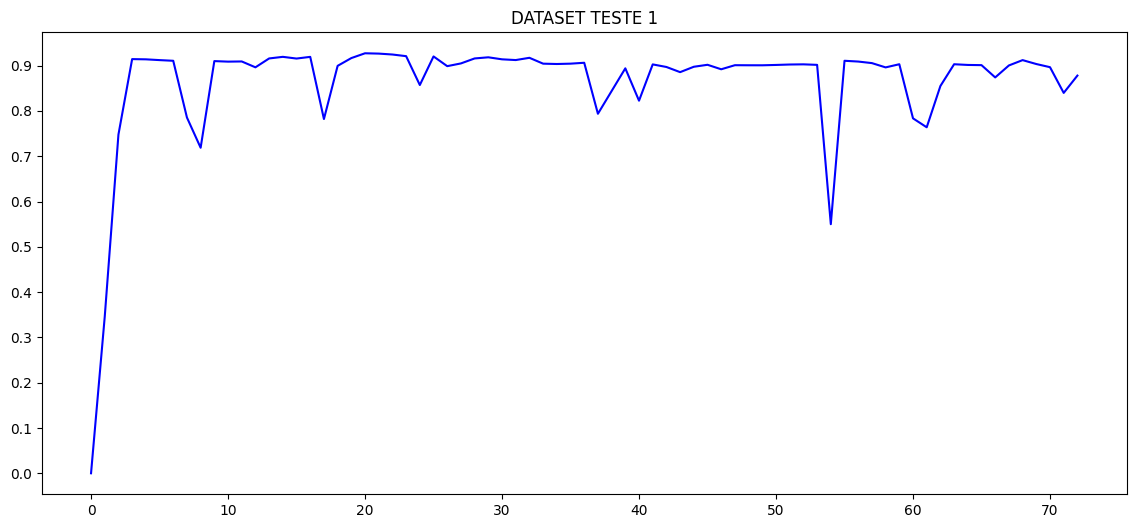

In [20]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_0, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

X shape (43, 1)
y shape (43, 30)


c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - loss: 0.8746 - val_loss: 0.8249
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8232 - val_loss: 0.7774
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7741 - val_loss: 0.7120
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6983 - val_loss: 0.6031
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5755 - val_loss: 0.3853
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3505 - val_loss: 0.1113
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1766 - val_loss: 0.0799
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1288 - val_loss: 0.0808
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1763 - val_loss: 0.0518
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1343 - val_loss: 0.0562
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1314 - val_loss: 0.0485
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━━

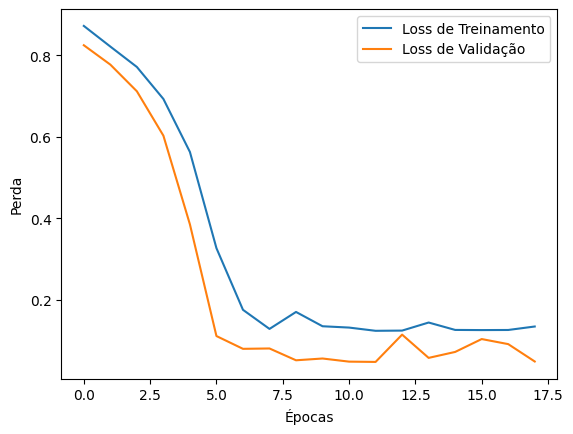

In [21]:
timesteps = config['datasets'][dataset_type]["timesteps"]
output_steps = config['datasets'][dataset_type]["output_horizon"]
X_0, y_0 = create_dataset(dataset_test_0, timesteps, output_steps)
X_0 = X_0.reshape(X_0.shape[0], X_0.shape[1], 1)
X_train, X_test, y_train, y_test = train_test_split(X_0, y_0, test_size=0.2, random_state=42)

model0 = Sequential()

for _ in range(int(config['datasets'][dataset_type]['layers'])):
    model0.add(LSTM(int(config['datasets'][dataset_type]['neurons']),
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                    #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                    return_sequences=True if _ < int(config['datasets'][dataset_type]["layers"]) - 1 else False, input_shape=(X_0.shape[1], 1)))

    model0.add(Dropout(config['datasets'][dataset_type]['dropout']))

model0.add(Dense(config['datasets'][dataset_type]['output_horizon'], 
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                    activation=config['datasets'][dataset_type]['activation']))

model0.summary()

# Configurar o otimizador
optimizer = config['datasets'][dataset_type]['optimizer']
    
if optimizer == 'adam':
    opt = Adam(learning_rate=config['datasets'][dataset_type]['learning_rate'])
elif optimizer == 'rmsprop':
    opt = RMSprop(learning_rate=config['datasets'][dataset_type]['learning_rate'])
else:
    opt = SGD(learning_rate=config['datasets'][dataset_type]['learning_rate'])

# Configurar a função de perda
loss_function = config['datasets'][dataset_type]["loss_function"]

if loss_function == "wmae":
    loss = wmae
elif loss_function == "wmse":
    loss = wmse

model0.compile(optimizer=opt, loss=loss)

early_stopping = EarlyStopping(monitor='val_loss', patience=config['datasets'][dataset_type]['patience'], restore_best_weights=True)

history = model0.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                verbose=1, callbacks=[early_stopping])
    
plt.plot(history.history['loss'], label='Loss de Treinamento')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step


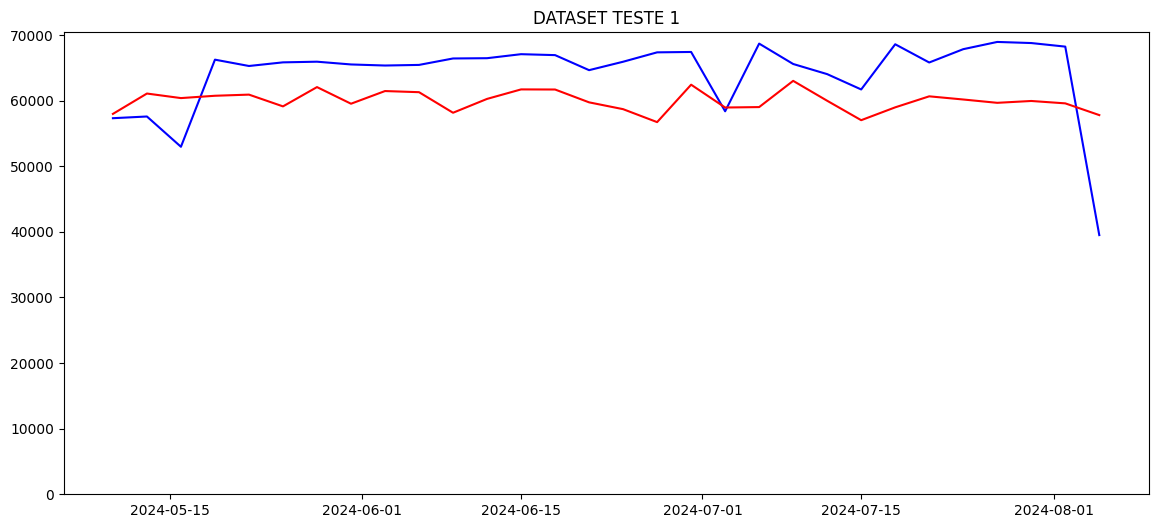

In [23]:
pred = model0.predict(duas_unas_validation_scaled.iloc[0])
y_pred_rescaled = scalers[4].inverse_transform(pred)
y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("DATASET TESTE 1")
plt.show()

In [24]:
avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

[57325.32 57584.52 52969.32 66248.64 65283.48 65837.16 65937.96 65518.2
 65354.76 65447.64 66429.72 66471.48 67083.12 66940.2  64648.08 65931.48
 67363.2  67420.8  58378.32 68695.2  65588.4  64043.28 61705.8  68594.76
 65816.64 67846.32 68950.08 68780.88 68236.2  39506.76]
 
[57982.258 61083.79  60390.523 60745.156 60919.71  59126.793 62066.367
 59532.164 61463.906 61290.395 58156.008 60266.535 61714.273 61697.59
 59741.285 58702.61  56727.773 62432.92  58953.64  59019.99  63017.35
 59983.438 57021.508 58979.816 60659.223 60175.66  59669.25  59950.176
 59586.855 57798.957]
 
MAE(Erro absoluto médio) Score of LSTM model =  6265.722
 
MSE(Erro quadrático médio) Score of LSTM model =  50444507.143
 
RMSE(Raiz do erro quadrático médio) Score of LSTM model =  7102.43
 
MAPE(Erro percentual médio absoluto) Score of LSTM model =  0.1
 
2% Accuracy Score of LSTM model =  6.67
5% Accuracy Score of LSTM model =  10.0
10% Accuracy Score of LSTM model =  60.0


(6265.72, 50444507.14, 7102.43, 0.1, 6.67, 10.0, 60.0)

In [25]:
acumulado_1mes_real = duas_unas_validation_rescaled[:10].sum()
acumulado_2mes_real = duas_unas_validation_rescaled[:20].sum()
acumulado_3mes_real = duas_unas_validation_rescaled[:30].sum()

acumulado_1mes_pred = y_pred_rescaled[:10].sum()
acumulado_2mes_pred = y_pred_rescaled[:20].sum()
acumulado_3mes_pred = y_pred_rescaled[:30].sum()

print("Erro percentual acumulado 30 dias:", round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2),"%")
print("Erro percentual acumulado 60 dias:", round(((abs(acumulado_2mes_real-acumulado_2mes_pred))/acumulado_2mes_real)*100, 2),"%")
print("Erro percentual acumulado 90 dias:", round(((abs(acumulado_3mes_real-acumulado_3mes_pred))/acumulado_3mes_real)*100, 2),"%")


Erro percentual acumulado 30 dias: 3.65 %
Erro percentual acumulado 60 dias: 6.59 %
Erro percentual acumulado 90 dias: 6.6 %


## **TESTE 01**
Prata I, II, III e Duas Unas.
Ações a serem testadas:

0. Validar se a técnica de TL que envolve congelamento de camadas é reconhecido e amplamente utilizado;
1. Padronizar cada dataset em separado (Prata I, II, III);
2. Concatenar os datasets;
3. Pré-treinar o modelo com o novo dataset;
4. Padronizar o dataset Duas Unas em separado;
5. Retirar do dataset Duas os dados de teste;
6. Congelar parte das camadas e treinar o modelo novamente com taxa de aprendizado reduzida, mas agora com o dataset Duas Unas;
7. Validar o modelo com os dados de teste.

In [19]:
### DATASETS PARA TESTE 01 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [1, 2, 3]
dataset_test_1 = concatenate_selected_datasets(scaled_datasets, indices)

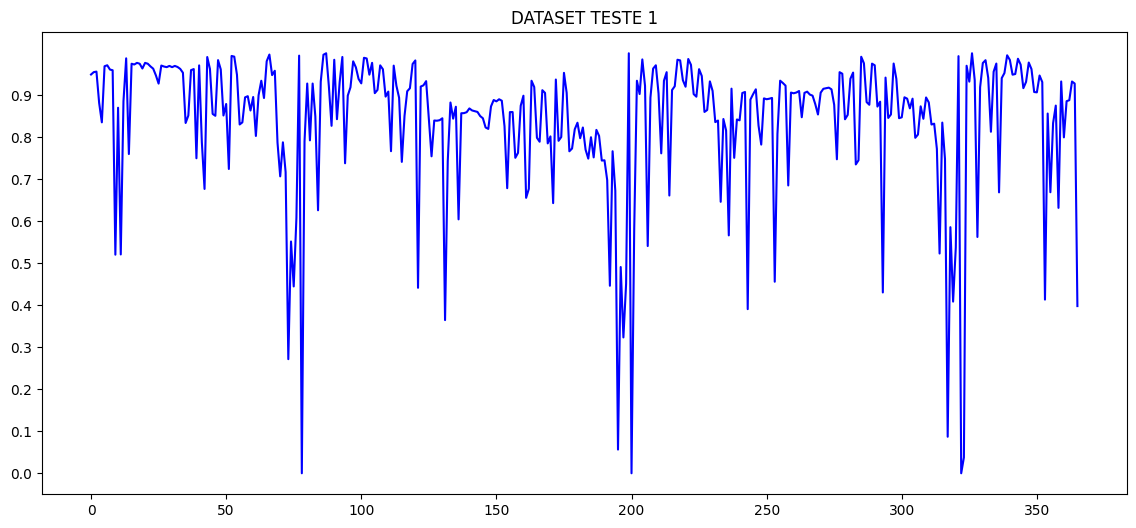

In [20]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_1, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

X shape (336, 1)
y shape (336, 30)


c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.7402 - val_loss: 0.2159
Epoch 2/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2027 - val_loss: 0.1643
Epoch 3/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1774 - val_loss: 0.1151
Epoch 4/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1664 - val_loss: 0.1289
Epoch 5/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1607 - val_loss: 0.1810
Epoch 6/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1609 - val_loss: 0.1564
Epoch 7/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1556 - val_loss: 0.1334
Epoch 8/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1505 - val_loss: 0.1247
Epoch 9/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1420 - val_loss: 0.1198


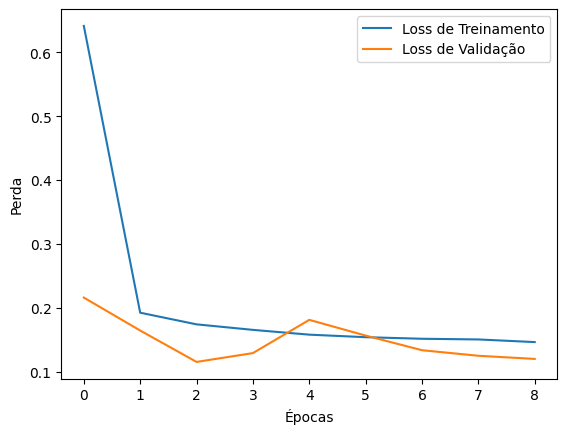

Epoch 1/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1770 - val_loss: 0.1065
Epoch 2/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1737 - val_loss: 0.0944
Epoch 3/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1618 - val_loss: 0.0870
Epoch 4/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1607 - val_loss: 0.0927
Epoch 5/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1543 - val_loss: 0.0868
Epoch 6/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1584 - val_loss: 0.1022
Epoch 7/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1518 - val_loss: 0.0979
Epoch 8/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1534 - val_loss: 0.0862
Epoch 9/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1460 - val_loss: 0.0914
Epoch 10/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1491 - val_loss: 0.0864
Epoch 11/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1457 - val_loss: 0.0866
Epoch 12/100000
17/17 ━━━━━━━━

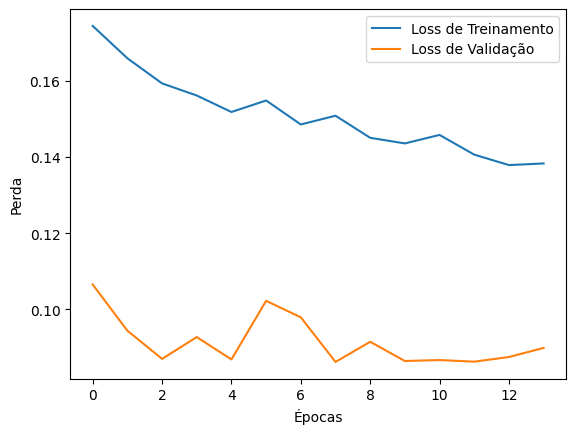

Epoch 1/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1358 - val_loss: 0.1348
Epoch 2/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1355 - val_loss: 0.1334
Epoch 3/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1302 - val_loss: 0.1352
Epoch 4/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1282 - val_loss: 0.1338
Epoch 5/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1320 - val_loss: 0.1343
Epoch 6/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1284 - val_loss: 0.1337


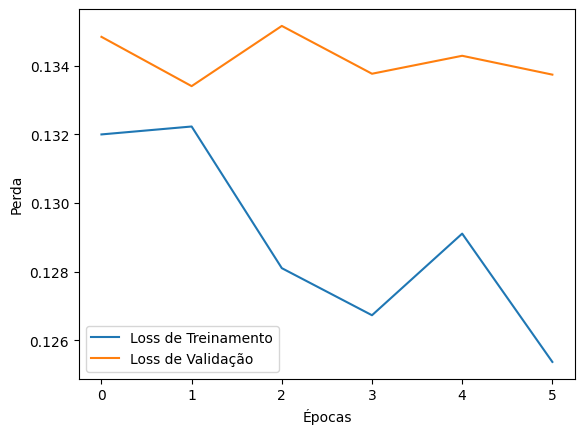

Epoch 1/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1323 - val_loss: 0.1229
Epoch 2/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1338 - val_loss: 0.1235
Epoch 3/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1329 - val_loss: 0.1235
Epoch 4/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1337 - val_loss: 0.1227
Epoch 5/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1268 - val_loss: 0.1228
Epoch 6/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1311 - val_loss: 0.1238


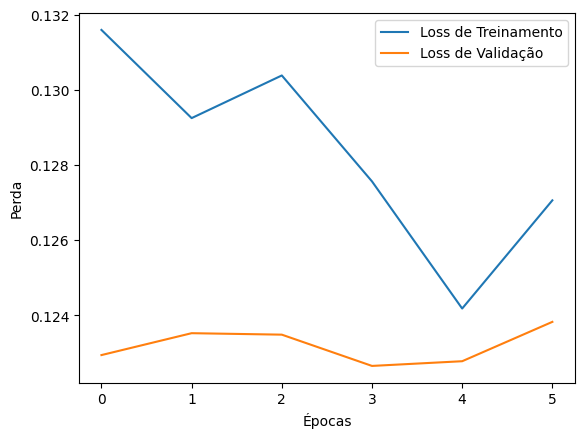

In [21]:
timesteps = config['datasets'][dataset_type]["timesteps"]
output_steps = config['datasets'][dataset_type]["output_horizon"]
X_1, y_1 = create_dataset(dataset_test_1, timesteps, output_steps)
X_1 = X_1.reshape(X_1.shape[0], X_1.shape[1], 1)

model1 = create_model(config, dataset_type, X_1, y_1, 4)

In [22]:
# Salvamento dos pesos após primeiro treinamento

pesos_treinamento1 = model1.get_weights()
pesos_LSTM1_t1 = model1.layers[0].get_weights()
pesos_LSTM2_t1 = model1.layers[2].get_weights()
pesos_LSTM3_t1 = model1.layers[4].get_weights()
pesos_DENSE_t1 = model1.layers[6].get_weights()

# Salvar pesos de cada camada LSTM em arquivos .npz
np.savez(os.path.join(diretorio_pesos_teste_1, "pesos_LSTM1_t1.npz"), *pesos_LSTM1_t1)
np.savez(os.path.join(diretorio_pesos_teste_1, "pesos_LSTM2_t1.npz"), *pesos_LSTM2_t1)
np.savez(os.path.join(diretorio_pesos_teste_1, "pesos_LSTM3_t1.npz"), *pesos_LSTM3_t1)
np.savez(os.path.join(diretorio_pesos_teste_1, "pesos_DENSE_t1.npz"), *pesos_DENSE_t1)

# Para salvar os pesos do modelo completo
np.savez(os.path.join(diretorio_pesos_teste_1, "pesos_modelo.npz"), *pesos_treinamento1)

In [23]:
# Carregar pesos do arquivo .npz
pesos_carregados_LSTM1_t1 = np.load(os.path.join(diretorio_pesos_teste_1, "pesos_LSTM1_t1.npz"))
pesos_carregados_LSTM2_t1 = np.load(os.path.join(diretorio_pesos_teste_1, "pesos_LSTM2_t1.npz"))
pesos_carregados_LSTM3_t1 = np.load(os.path.join(diretorio_pesos_teste_1, "pesos_LSTM3_t1.npz"))

In [24]:
X, y = create_dataset(scaled_datasets[4], timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)

model1_ft = Sequential()

for _ in range(int(config['datasets'][dataset_type]['layers'])):
    model1_ft.add(LSTM(int(config['datasets'][dataset_type]['neurons']),
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                    #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                    return_sequences=True if _ < int(config['datasets'][dataset_type]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

    model1_ft.add(Dropout(0.3))

model1_ft.add(Dense(config['datasets'][dataset_type]['output_horizon'], 
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                    activation=config['datasets'][dataset_type]['activation']))

model1_ft.summary()

X shape (43, 1)
y shape (43, 30)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Caminho dos pesos salvos
caminho_LSTM1_t1 = os.path.join(diretorio_pesos_teste_1, "pesos_LSTM1_t1.npz")
caminho_LSTM2_t1 = os.path.join(diretorio_pesos_teste_1, "pesos_LSTM2_t1.npz")
caminho_LSTM3_t1 = os.path.join(diretorio_pesos_teste_1, "pesos_LSTM3_t1.npz")

carregar_e_aplicar_pesos(model1_ft, caminho_LSTM1_t1, caminho_LSTM2_t1, caminho_LSTM3_t1)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)


In [26]:
# Verifica se os pesos de cada camada do novo modelo são iguais ao pesos salvos anteriormente

### CAMADA LSTM 1
sao_iguais1 = np.array_equal(pesos_LSTM1_t1[0], model1_ft.layers[0].get_weights()[0])
sao_iguais2 = np.array_equal(pesos_LSTM1_t1[1], model1_ft.layers[0].get_weights()[1])
sao_iguais3 = np.array_equal(pesos_LSTM1_t1[2], model1_ft.layers[0].get_weights()[2])

print(sao_iguais1)
print(sao_iguais2)
print(sao_iguais3)

### CAMADA LSTM 2
sao_iguais1 = np.array_equal(pesos_LSTM2_t1[0], model1_ft.layers[2].get_weights()[0])
sao_iguais2 = np.array_equal(pesos_LSTM2_t1[1], model1_ft.layers[2].get_weights()[1])
sao_iguais3 = np.array_equal(pesos_LSTM2_t1[2], model1_ft.layers[2].get_weights()[2])

print(sao_iguais1)
print(sao_iguais2)
print(sao_iguais3)

### CAMADA LSTM 3
sao_iguais1 = np.array_equal(pesos_LSTM3_t1[0], model1_ft.layers[4].get_weights()[0])
sao_iguais2 = np.array_equal(pesos_LSTM3_t1[1], model1_ft.layers[4].get_weights()[1])
sao_iguais3 = np.array_equal(pesos_LSTM3_t1[2], model1_ft.layers[4].get_weights()[2])

print(sao_iguais1)
print(sao_iguais2)
print(sao_iguais3)


True
True
True
True
True
True
True
True
True


In [27]:
congelar_camadas(model1_ft)

LSTM 1 treinable:  False
LSTM 2 treinable:  False


Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step - loss: 0.8307 - val_loss: 0.7573
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.7595 - val_loss: 0.6728
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6766 - val_loss: 0.5783
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.5757 - val_loss: 0.4733
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4804 - val_loss: 0.3677
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3656 - val_loss: 0.2635
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2618 - val_loss: 0.1804
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1979 - val_loss: 0.1221
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1640 - val_loss: 0.0897
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1372 - val_loss: 0.0719
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1152 - val_loss: 0.0618
Epoch 12/100000
2/2 ━━━━━━━━━━━━━━━━━━━━

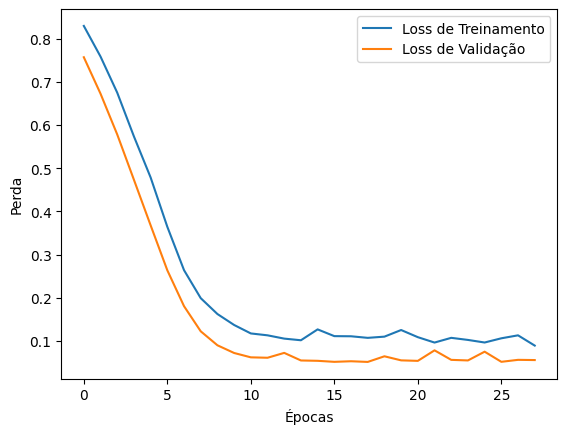

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

learning_rate = 0.005

# Configurar o otimizador
optimizer = config['datasets'][dataset_type]['optimizer']
    
if optimizer == 'adam':
    opt = Adam(learning_rate=learning_rate)
elif optimizer == 'rmsprop':
    opt = RMSprop(learning_rate=learning_rate)
else:
    opt = SGD(learning_rate=learning_rate)

# Configurar a função de perda
loss_function = config['datasets'][dataset_type]["loss_function"]

if loss_function == "wmae":
    loss = wmae
elif loss_function == "wmse":
    loss = wmse

model1_ft.compile(optimizer=opt, loss=loss)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) 

history = model1_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                verbose=1, callbacks=[early_stopping])
    
plt.plot(history.history['loss'], label='Loss de Treinamento')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

In [29]:
descongelar_camadas(model1_ft)

LSTM 1 treinable:  True
LSTM 2 treinable:  True


Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 341ms/step - loss: 0.1068 - val_loss: 0.0515
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1099 - val_loss: 0.0505
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1001 - val_loss: 0.0502
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1045 - val_loss: 0.0499
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1070 - val_loss: 0.0445
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0982 - val_loss: 0.0434
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0896 - val_loss: 0.0452
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0960 - val_loss: 0.0443
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1190 - val_loss: 0.0417
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0986 - val_loss: 0.0432
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0994 - val_loss: 0.0421
Epoch 12/100000
2/2 ━━━━━━━━━━━━━━━━━━━━

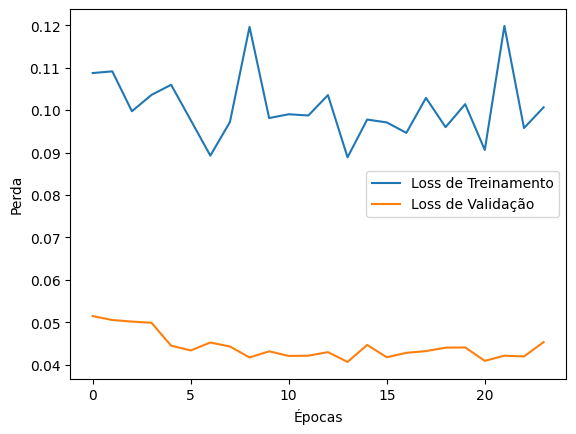

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

learning_rate = 0.0008

# Configurar o otimizador
optimizer = config['datasets'][dataset_type]['optimizer']
    
if optimizer == 'adam':
    opt = Adam(learning_rate=learning_rate)
elif optimizer == 'rmsprop':
    opt = RMSprop(learning_rate=learning_rate)
else:
    opt = SGD(learning_rate=learning_rate)

# Configurar a função de perda
loss_function = config['datasets'][dataset_type]["loss_function"]

if loss_function == "wmae":
    loss = wmae
elif loss_function == "wmse":
    loss = wmse

model1_ft.compile(optimizer=opt, loss=loss)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) 

history = model1_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                verbose=1, callbacks=[early_stopping])
    
plt.plot(history.history['loss'], label='Loss de Treinamento')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 904ms/step


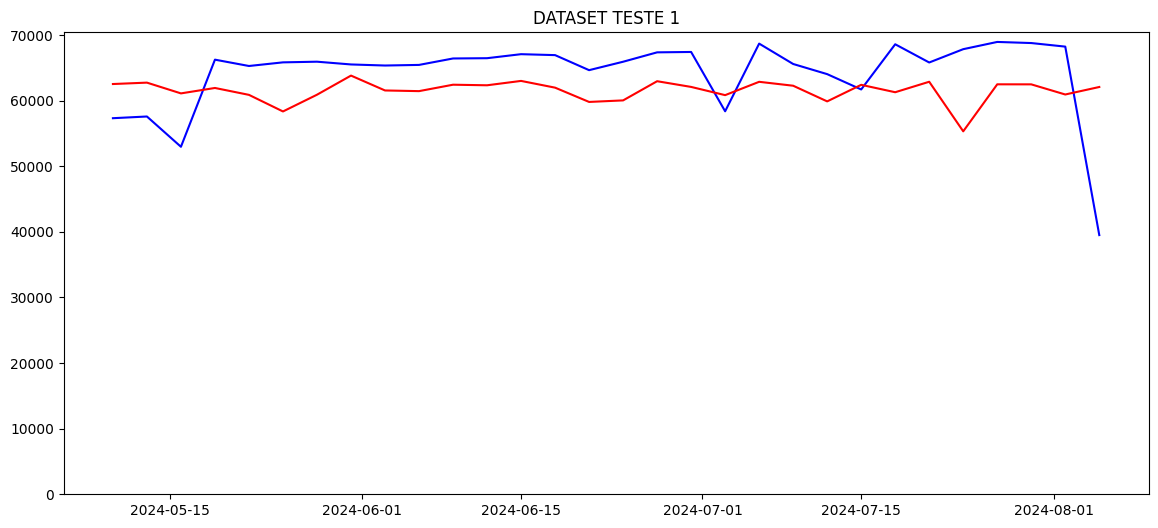

In [31]:
pred = model1_ft.predict(duas_unas_validation_scaled.iloc[0])
y_pred_rescaled = scalers[4].inverse_transform(pred)
y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("DATASET TESTE 1")
plt.show()

In [32]:
avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

[57325.32 57584.52 52969.32 66248.64 65283.48 65837.16 65937.96 65518.2
 65354.76 65447.64 66429.72 66471.48 67083.12 66940.2  64648.08 65931.48
 67363.2  67420.8  58378.32 68695.2  65588.4  64043.28 61705.8  68594.76
 65816.64 67846.32 68950.08 68780.88 68236.2  39506.76]
 
[62534.28  62747.094 61106.45  61933.953 60882.38  58352.82  60905.31
 63820.72  61553.312 61450.832 62429.832 62342.492 63008.953 61981.1
 59804.117 60038.754 62962.715 62093.1   60840.434 62872.016 62274.91
 59887.48  62412.23  61283.477 62880.92  55325.203 62489.754 62484.273
 60938.305 62081.53 ]
 
MAE(Erro absoluto médio) Score of LSTM model =  5624.098
 
MSE(Erro quadrático médio) Score of LSTM model =  46154835.596
 
RMSE(Raiz do erro quadrático médio) Score of LSTM model =  6793.735
 
MAPE(Erro percentual médio absoluto) Score of LSTM model =  0.09
 
2% Accuracy Score of LSTM model =  3.33
5% Accuracy Score of LSTM model =  13.33
10% Accuracy Score of LSTM model =  80.0


(5624.1, 46154835.6, 6793.74, 0.09, 3.33, 13.33, 80.0)

In [33]:
acumulado_1mes_real = duas_unas_validation_rescaled[:10].sum()
acumulado_1e2mes_real = duas_unas_validation_rescaled[:20].sum()
acumulado_1e2e3mes_real = duas_unas_validation_rescaled[:30].sum()
acumulado_2mes_real = duas_unas_validation_rescaled[10:20].sum()
acumulado_3mes_real = duas_unas_validation_rescaled[20:30].sum()

acumulado_1mes_pred = y_pred_rescaled[:10].sum()
acumulado_1e2mes_pred = y_pred_rescaled[:20].sum()
acumulado_1e2e3mes_pred = y_pred_rescaled[:30].sum()
acumulado_2mes_pred = y_pred_rescaled[10:20].sum()
acumulado_3mes_pred = y_pred_rescaled[20:30].sum()

print("Erro percentual acumulado 30 dias:", round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2),"%")
print("Erro percentual acumulado 60 dias:", round(((abs(acumulado_1e2mes_real-acumulado_1e2mes_pred))/acumulado_1e2mes_real)*100, 2),"%")
print("Erro percentual acumulado 90 dias:", round(((abs(acumulado_1e2e3mes_real-acumulado_1e2e3mes_pred))/acumulado_1e2e3mes_real)*100, 2),"%")
print(" ")
print("Erro percentual acumulado 1º mês:", round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2),"%")
print("Erro percentual acumulado 2º mês:", round(((abs(acumulado_2mes_real-acumulado_2mes_pred))/acumulado_2mes_real)*100, 2),"%")
print("Erro percentual acumulado 3º mês:", round(((abs(acumulado_3mes_real-acumulado_3mes_pred))/acumulado_3mes_real)*100, 2),"%")


Erro percentual acumulado 30 dias: 1.95 %
Erro percentual acumulado 60 dias: 4.13 %
Erro percentual acumulado 90 dias: 4.17 %
 
Erro percentual acumulado 1º mês: 1.95 %
Erro percentual acumulado 2º mês: 6.22 %
Erro percentual acumulado 3º mês: 4.23 %


## **TESTE 02**

Prata I, II, III e Duas Unas.
Ações a serem testadas:
1. Padronizar cada dataset em separado (Prata I, II, III e Duas Unas);
2. Retirar do dataset Duas os dados de teste;
3. Concatenar os datasets;
4. Treinar o modelo com o novo dataset;
5. Validar o modelo com os dados de teste.

In [34]:
### DATASETS PARA TESTE 02 ###

indices = [1, 2, 3, 4]
dataset_test_2 = concatenate_selected_datasets(scaled_datasets, indices)

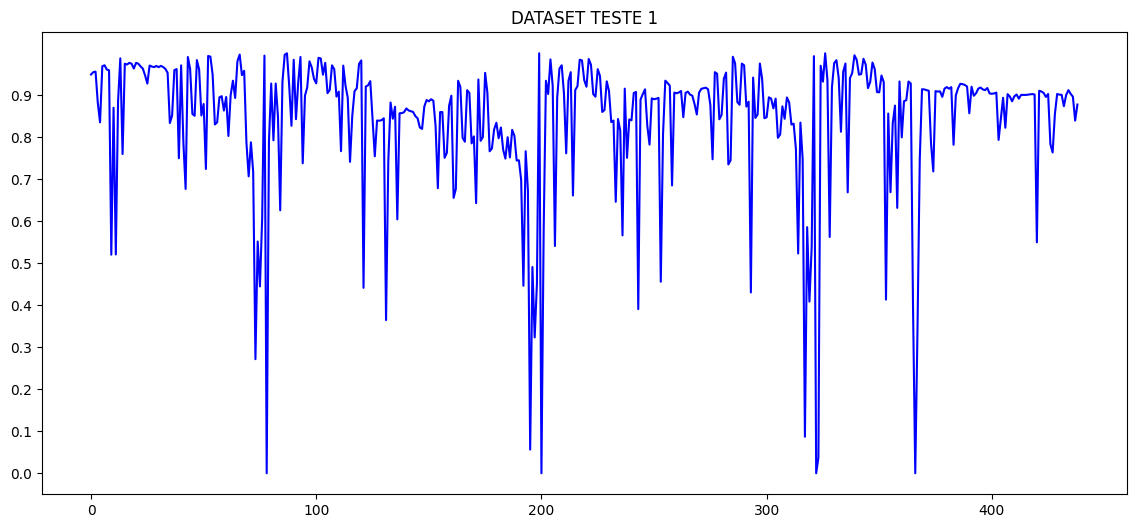

In [35]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_2, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [36]:
timesteps = config['datasets'][dataset_type]["timesteps"]
output_steps = config['datasets'][dataset_type]["output_horizon"]
X, y = create_dataset(dataset_test_2, timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("X_train shape", np.array(X_train).shape)
# print("y_train shape", np.array(y_train).shape)
# print("X_test shape", np.array(X_test).shape)
# print("y_test shape", np.array(y_test).shape)

X shape (409, 1)
y shape (409, 30)


c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.6984 - val_loss: 0.1181
Epoch 2/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1818 - val_loss: 0.1323
Epoch 3/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1750 - val_loss: 0.1490
Epoch 4/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1630 - val_loss: 0.1457
Epoch 5/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1517 - val_loss: 0.1118
Epoch 6/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1396 - val_loss: 0.1292
Epoch 7/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1432 - val_loss: 0.1511
Epoch 8/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1414 - val_loss: 0.1366
Epoch 9/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1401 - val_loss: 0.1138
Epoch 10/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1298 - val_loss: 0.1189
Epoch 11/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1316 - val_loss: 0.1388


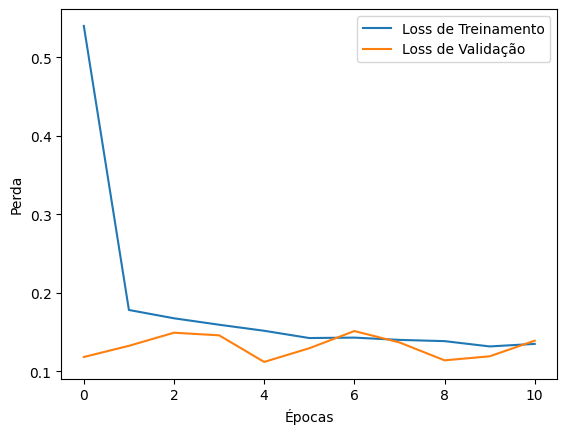

Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1410 - val_loss: 0.1316
Epoch 2/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1356 - val_loss: 0.1226
Epoch 3/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1316 - val_loss: 0.1319
Epoch 4/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1303 - val_loss: 0.1209
Epoch 5/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1244 - val_loss: 0.1309
Epoch 6/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1254 - val_loss: 0.1304


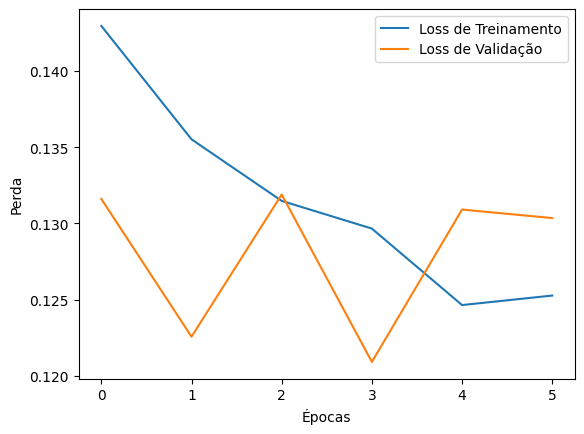

Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1504 - val_loss: 0.0985
Epoch 2/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1387 - val_loss: 0.0979
Epoch 3/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1400 - val_loss: 0.0985
Epoch 4/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1283 - val_loss: 0.1086
Epoch 5/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1374 - val_loss: 0.0971
Epoch 6/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1259 - val_loss: 0.1025
Epoch 7/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1268 - val_loss: 0.0972
Epoch 8/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1287 - val_loss: 0.0983
Epoch 9/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1255 - val_loss: 0.0970
Epoch 10/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1245 - val_loss: 0.0969
Epoch 11/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1261 - val_loss: 0.0980
Epoch 12/100000
21/21 ━━━━━━━

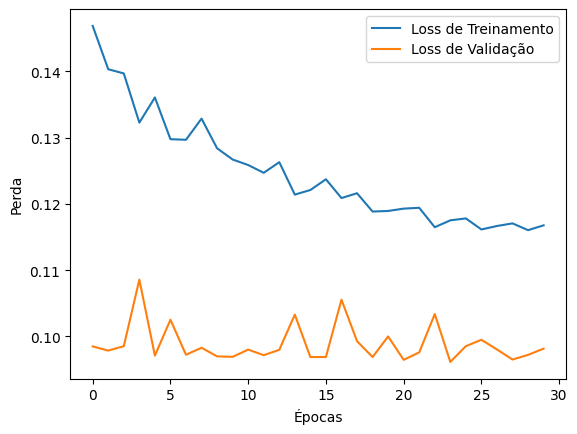

Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1120 - val_loss: 0.0943
Epoch 2/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1113 - val_loss: 0.0982
Epoch 3/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1131 - val_loss: 0.1074
Epoch 4/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1119 - val_loss: 0.0985
Epoch 5/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1121 - val_loss: 0.0990
Epoch 6/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1097 - val_loss: 0.1018
Epoch 7/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1098 - val_loss: 0.0947


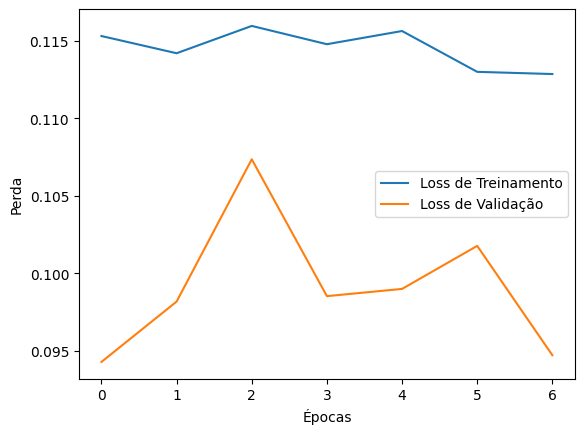

In [37]:
model_2 = create_model(config, dataset_type, X, y, 4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step


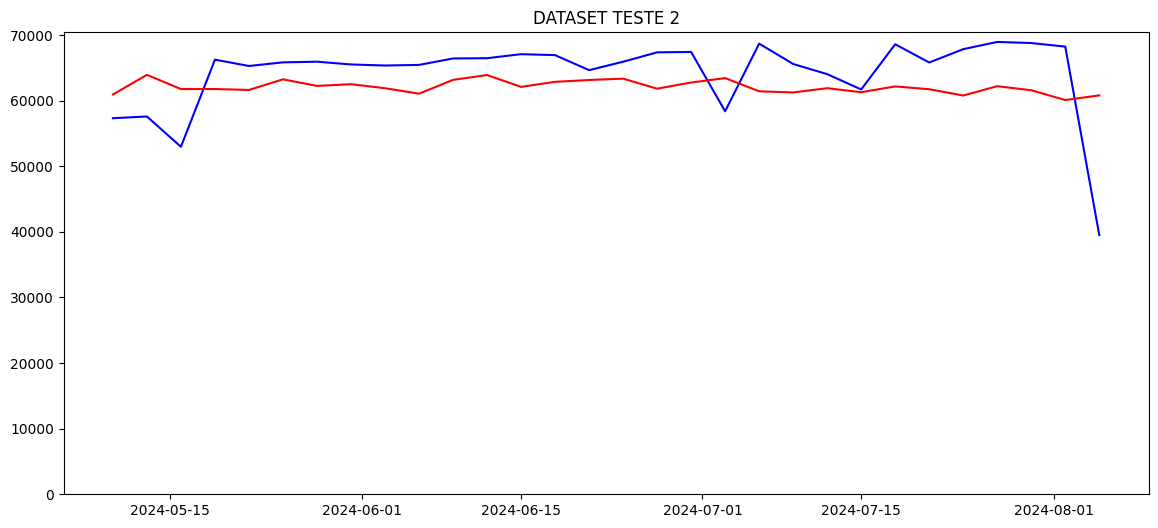

In [38]:
pred = model_2.predict(duas_unas_validation_scaled.iloc[0])
y_pred_rescaled = scalers[4].inverse_transform(pred)
y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("DATASET TESTE 2")
plt.show()

In [39]:
avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

[57325.32 57584.52 52969.32 66248.64 65283.48 65837.16 65937.96 65518.2
 65354.76 65447.64 66429.72 66471.48 67083.12 66940.2  64648.08 65931.48
 67363.2  67420.8  58378.32 68695.2  65588.4  64043.28 61705.8  68594.76
 65816.64 67846.32 68950.08 68780.88 68236.2  39506.76]
 
[60939.47  63932.69  61768.67  61770.766 61629.63  63253.355 62246.133
 62510.055 61895.266 61066.484 63167.586 63904.777 62101.7   62869.5
 63148.812 63355.074 61823.266 62767.688 63434.137 61429.28  61252.195
 61898.383 61286.684 62171.06  61742.188 60782.52  62203.695 61584.934
 60095.883 60803.61 ]
 
MAE(Erro absoluto médio) Score of LSTM model =  5111.03
 
MSE(Erro quadrático médio) Score of LSTM model =  39045460.687
 
RMSE(Raiz do erro quadrático médio) Score of LSTM model =  6248.637
 
MAPE(Erro percentual médio absoluto) Score of LSTM model =  0.09
 
2% Accuracy Score of LSTM model =  3.33
5% Accuracy Score of LSTM model =  26.67
10% Accuracy Score of LSTM model =  76.67


(5111.03, 39045460.69, 6248.64, 0.09, 3.33, 26.67, 76.67)

In [40]:
acumulado_1mes_real = duas_unas_validation_rescaled[:10].sum()
acumulado_2mes_real = duas_unas_validation_rescaled[:20].sum()
acumulado_3mes_real = duas_unas_validation_rescaled[:30].sum()

acumulado_1mes_pred = y_pred_rescaled[:10].sum()
acumulado_2mes_pred = y_pred_rescaled[:20].sum()
acumulado_3mes_pred = y_pred_rescaled[:30].sum()

print("Erro percentual acumulado 30 dias:", round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2),"%")
print("Erro percentual acumulado 60 dias:", round(((abs(acumulado_2mes_real-acumulado_2mes_pred))/acumulado_2mes_real)*100, 2),"%")
print("Erro percentual acumulado 90 dias:", round(((abs(acumulado_3mes_real-acumulado_3mes_pred))/acumulado_3mes_real)*100, 2),"%")


Erro percentual acumulado 30 dias: 1.03 %
Erro percentual acumulado 60 dias: 2.94 %
Erro percentual acumulado 90 dias: 3.28 %


## **TESTE 03**

Prata I, II, III, Pirapama e Duas Unas.
Ações a serem testadas:
1. Padronizar cada dataset em separado (Prata I, II, III e Pirapama);
2. Concatenar os datasets;
3. Pré-treinar o modelo com o novo dataset;
4. Padronizar o dataset Duas Unas em separado;
5. Retirar do dataset Duas os dados de teste;
6. Congelar parte das camadas e treinar o modelo novamente com taxa de aprendizado reduzida, mas agora com o dataset Duas Unas;
7. Validar o modelo com os dados de teste.

In [41]:
### DATASETS PARA TESTE 03 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [0, 1, 2, 3]
dataset_test_3 = concatenate_selected_datasets(scaled_datasets, indices)

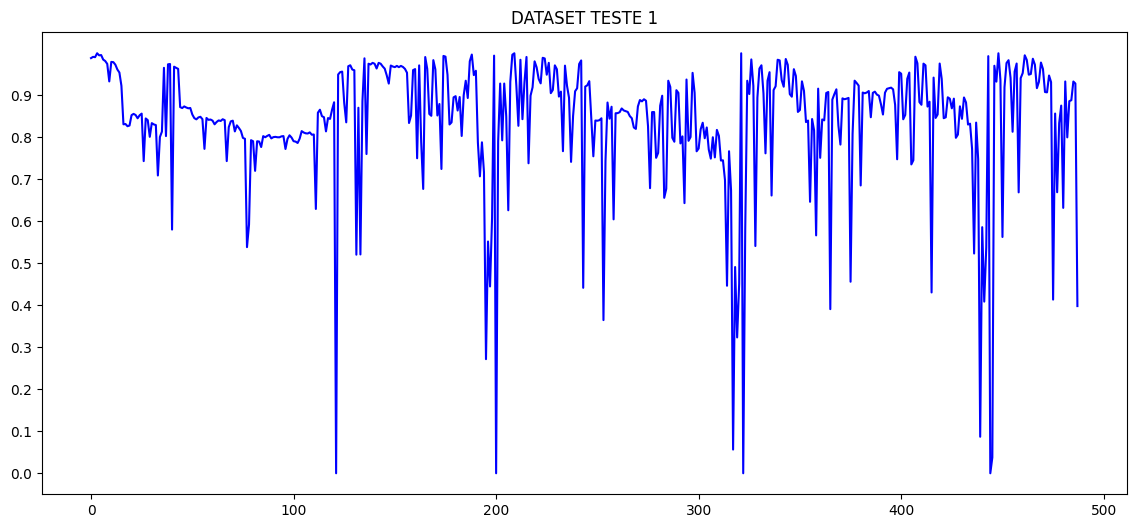

In [42]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_3, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

X shape (458, 1)
y shape (458, 30)


c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.7183 - val_loss: 0.0986
Epoch 2/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1803 - val_loss: 0.0921
Epoch 3/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1733 - val_loss: 0.1031
Epoch 4/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1650 - val_loss: 0.1072
Epoch 5/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1537 - val_loss: 0.0977
Epoch 6/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1523 - val_loss: 0.0813
Epoch 7/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1455 - val_loss: 0.0972
Epoch 8/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1469 - val_loss: 0.0868
Epoch 9/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1409 - val_loss: 0.0860
Epoch 10/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1372 - val_loss: 0.0804
Epoch 11/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1360 - val_loss: 0.0924
Epoch 12/100000
21/21 ━━━━━━━

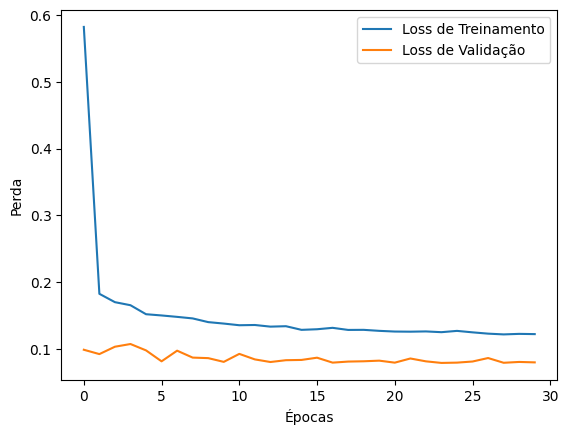

Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1080 - val_loss: 0.1196
Epoch 2/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1068 - val_loss: 0.1181
Epoch 3/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1069 - val_loss: 0.1158
Epoch 4/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1061 - val_loss: 0.1152
Epoch 5/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1058 - val_loss: 0.1153
Epoch 6/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1052 - val_loss: 0.1161


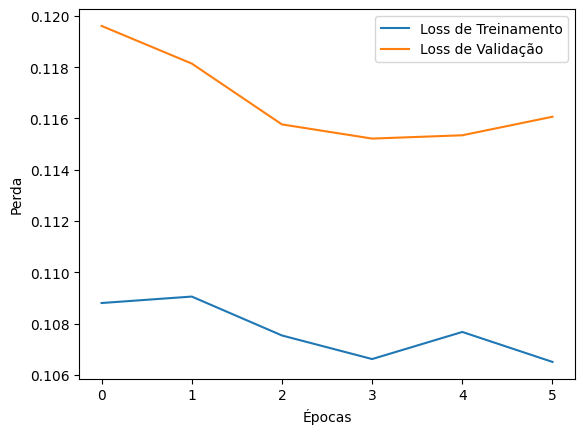

Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1103 - val_loss: 0.1249
Epoch 2/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1093 - val_loss: 0.1239
Epoch 3/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1093 - val_loss: 0.1321
Epoch 4/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1080 - val_loss: 0.1211
Epoch 5/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1090 - val_loss: 0.1250
Epoch 6/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1085 - val_loss: 0.1264


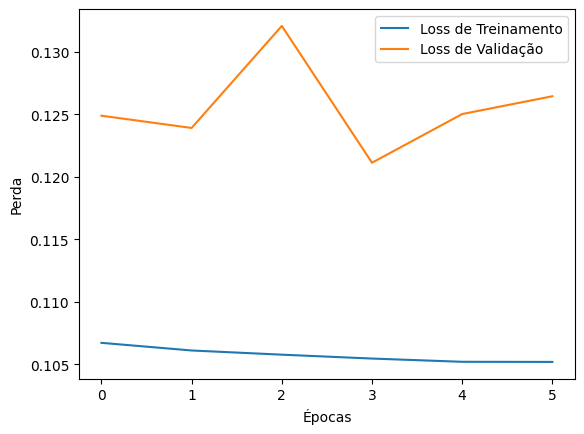

In [43]:
timesteps = config['datasets'][dataset_type]["timesteps"]
output_steps = config['datasets'][dataset_type]["output_horizon"]
X_3, y_3 = create_dataset(dataset_test_3, timesteps, output_steps)
X_3 = X_3.reshape(X_3.shape[0], X_3.shape[1], 1)

model3 = create_model(config, dataset_type, X_3, y_3, 3)

In [44]:
# Salvamento dos pesos após primeiro treinamento

pesos_treinamento3 = model3.get_weights()
pesos_LSTM1_t3 = model3.layers[0].get_weights()
pesos_LSTM2_t3 = model3.layers[2].get_weights()
pesos_LSTM3_t3 = model3.layers[4].get_weights()
pesos_DENSE_t3 = model3.layers[6].get_weights()

# Salvar pesos de cada camada LSTM em arquivos .npz
np.savez(os.path.join(diretorio_pesos_teste_3, "pesos_LSTM1_t3.npz"), *pesos_LSTM1_t3)
np.savez(os.path.join(diretorio_pesos_teste_3, "pesos_LSTM2_t3.npz"), *pesos_LSTM2_t3)
np.savez(os.path.join(diretorio_pesos_teste_3, "pesos_LSTM3_t3.npz"), *pesos_LSTM3_t3)
np.savez(os.path.join(diretorio_pesos_teste_3, "pesos_DENSE_t3.npz"), *pesos_DENSE_t3)

# Para salvar os pesos do modelo completo
np.savez(os.path.join(diretorio_pesos_teste_3, "pesos_modelo_t3.npz"), *pesos_treinamento3)

In [45]:
# Carregar pesos do arquivo .npz
pesos_carregados_LSTM1_t3 = np.load(os.path.join(diretorio_pesos_teste_3, "pesos_LSTM1_t3.npz"))
pesos_carregados_LSTM2_t3 = np.load(os.path.join(diretorio_pesos_teste_3, "pesos_LSTM2_t3.npz"))
pesos_carregados_LSTM3_t3 = np.load(os.path.join(diretorio_pesos_teste_3, "pesos_LSTM3_t3.npz"))

In [46]:
X, y = create_dataset(scaled_datasets[4], timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)

model3_ft = Sequential()

for _ in range(int(config['datasets'][dataset_type]['layers'])):
    model3_ft.add(LSTM(int(config['datasets'][dataset_type]['neurons']),
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                    #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                    return_sequences=True if _ < int(config['datasets'][dataset_type]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

    model3_ft.add(Dropout(0.3))

model3_ft.add(Dense(config['datasets'][dataset_type]['output_horizon'], 
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                    activation=config['datasets'][dataset_type]['activation']))

model3_ft.summary()

X shape (43, 1)
y shape (43, 30)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Caminho dos pesos salvos
caminho_LSTM1_t3 = os.path.join(diretorio_pesos_teste_3, "pesos_LSTM1_t3.npz")
caminho_LSTM2_t3 = os.path.join(diretorio_pesos_teste_3, "pesos_LSTM2_t3.npz")
caminho_LSTM3_t3 = os.path.join(diretorio_pesos_teste_3, "pesos_LSTM3_t3.npz")

carregar_e_aplicar_pesos(model3_ft, caminho_LSTM1_t3, caminho_LSTM2_t3, caminho_LSTM3_t3)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)


In [48]:
# Verifica se os pesos de cada camada do novo modelo são iguais ao pesos salvos anteriormente

### CAMADA LSTM 1
sao_iguais1 = np.array_equal(pesos_LSTM1_t3[0], model3_ft.layers[0].get_weights()[0])
sao_iguais2 = np.array_equal(pesos_LSTM1_t3[1], model3_ft.layers[0].get_weights()[1])
sao_iguais3 = np.array_equal(pesos_LSTM1_t3[2], model3_ft.layers[0].get_weights()[2])

print(sao_iguais1)
print(sao_iguais2)
print(sao_iguais3)

### CAMADA LSTM 2
sao_iguais1 = np.array_equal(pesos_LSTM2_t3[0], model3_ft.layers[2].get_weights()[0])
sao_iguais2 = np.array_equal(pesos_LSTM2_t3[1], model3_ft.layers[2].get_weights()[1])
sao_iguais3 = np.array_equal(pesos_LSTM2_t3[2], model3_ft.layers[2].get_weights()[2])

print(sao_iguais1)
print(sao_iguais2)
print(sao_iguais3)

### CAMADA LSTM 3
sao_iguais1 = np.array_equal(pesos_LSTM3_t3[0], model3_ft.layers[4].get_weights()[0])
sao_iguais2 = np.array_equal(pesos_LSTM3_t3[1], model3_ft.layers[4].get_weights()[1])
sao_iguais3 = np.array_equal(pesos_LSTM3_t3[2], model3_ft.layers[4].get_weights()[2])

print(sao_iguais1)
print(sao_iguais2)
print(sao_iguais3)

True
True
True
True
True
True
True
True
True


In [49]:
congelar_camadas(model3_ft)

LSTM 1 treinable:  False
LSTM 2 treinable:  False


Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 860ms/step - loss: 0.8597 - val_loss: 0.8176
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.8101 - val_loss: 0.7645
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.7590 - val_loss: 0.7088
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.7058 - val_loss: 0.6534
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.6444 - val_loss: 0.5912
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.5830 - val_loss: 0.5262
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.5201 - val_loss: 0.4569
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.4535 - val_loss: 0.3867
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.3771 - val_loss: 0.3109
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.3166 - val_loss: 0.2366
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.2294 - val_loss: 0.1797
Epoch 12/100000
2/2 ━━━━━━━━━━━━━━━━━━━━

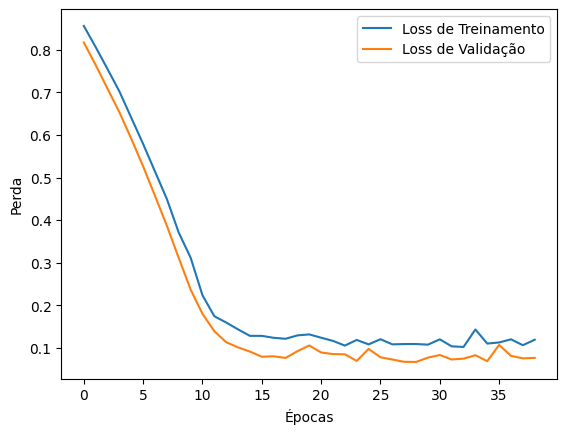

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

learning_rate = 0.005

# Configurar o otimizador
optimizer = config['datasets'][dataset_type]['optimizer']
    
if optimizer == 'adam':
    opt = Adam(learning_rate=learning_rate)
elif optimizer == 'rmsprop':
    opt = RMSprop(learning_rate=learning_rate)
else:
    opt = SGD(learning_rate=learning_rate)

# Configurar a função de perda
loss_function = config['datasets'][dataset_type]["loss_function"]

if loss_function == "wmae":
    loss = wmae
elif loss_function == "wmse":
    loss = wmse

model3_ft.compile(optimizer=opt, loss=loss)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) 

history = model3_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                verbose=1, callbacks=[early_stopping])
    
plt.plot(history.history['loss'], label='Loss de Treinamento')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

In [51]:
descongelar_camadas(model3_ft)

LSTM 1 treinable:  True
LSTM 2 treinable:  True


Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 934ms/step - loss: 0.1128 - val_loss: 0.0685
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1175 - val_loss: 0.0771
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1317 - val_loss: 0.0816
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1067 - val_loss: 0.0821
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1103 - val_loss: 0.0845
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.1146 - val_loss: 0.0836
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1132 - val_loss: 0.0851
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1109 - val_loss: 0.0773
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1150 - val_loss: 0.0736
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1225 - val_loss: 0.0735
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1065 - val_loss: 0.0733


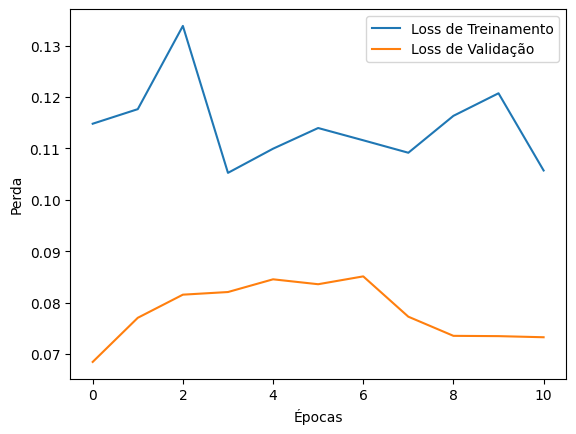

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

learning_rate = 0.0008

# Configurar o otimizador
optimizer = config['datasets'][dataset_type]['optimizer']
    
if optimizer == 'adam':
    opt = Adam(learning_rate=learning_rate)
elif optimizer == 'rmsprop':
    opt = RMSprop(learning_rate=learning_rate)
else:
    opt = SGD(learning_rate=learning_rate)

# Configurar a função de perda
loss_function = config['datasets'][dataset_type]["loss_function"]

if loss_function == "wmae":
    loss = wmae
elif loss_function == "wmse":
    loss = wmse

model3_ft.compile(optimizer=opt, loss=loss)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) 

history = model3_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                verbose=1, callbacks=[early_stopping])
    
plt.plot(history.history['loss'], label='Loss de Treinamento')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step


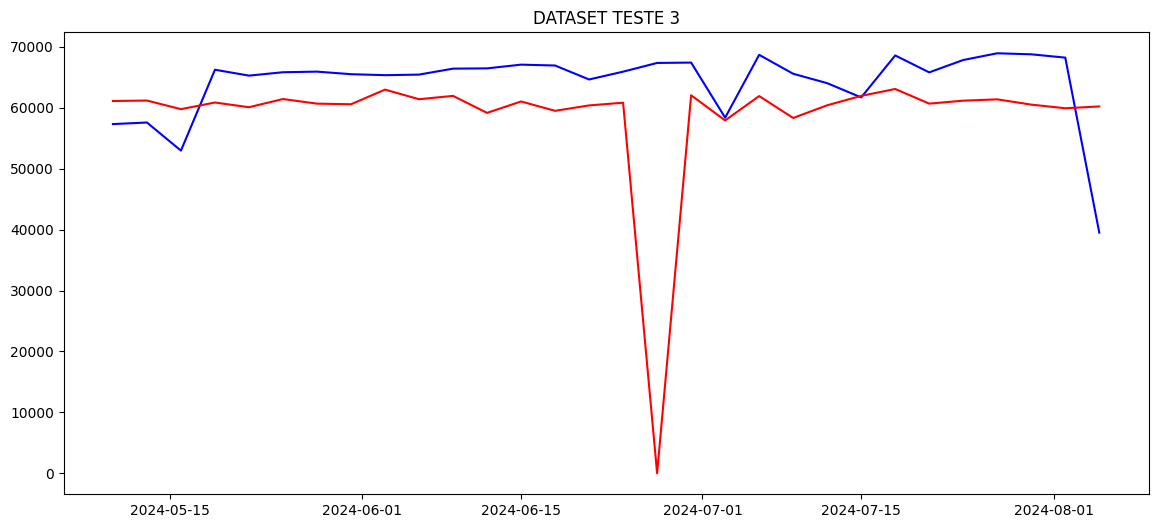

In [53]:
pred = model3_ft.predict(duas_unas_validation_scaled.iloc[0])
y_pred_rescaled = scalers[4].inverse_transform(pred)
y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("DATASET TESTE 3")
plt.show()

In [54]:
avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

[57325.32 57584.52 52969.32 66248.64 65283.48 65837.16 65937.96 65518.2
 65354.76 65447.64 66429.72 66471.48 67083.12 66940.2  64648.08 65931.48
 67363.2  67420.8  58378.32 68695.2  65588.4  64043.28 61705.8  68594.76
 65816.64 67846.32 68950.08 68780.88 68236.2  39506.76]
 
[61113.53  61191.32  59776.92  60867.375 60092.523 61436.63  60681.977
 60583.832 62983.363 61406.492 61956.074 59163.31  61037.29  59502.49
 60389.094 60836.57      0.    62055.297 57922.402 61924.69  58327.254
 60410.11  61956.668 63087.97  60684.36  61168.676 61386.652 60520.82
 59924.58  60220.973]
 
MAE(Erro absoluto médio) Score of LSTM model =  7788.796
 
MSE(Erro quadrático médio) Score of LSTM model =  194525559.953
 
RMSE(Raiz do erro quadrático médio) Score of LSTM model =  13947.242
 
MAPE(Erro percentual médio absoluto) Score of LSTM model =  0.12
 
2% Accuracy Score of LSTM model =  6.67
5% Accuracy Score of LSTM model =  10.0
10% Accuracy Score of LSTM model =  70.0


(7788.8, 194525559.95, 13947.24, 0.12, 6.67, 10.0, 70.0)

In [55]:
acumulado_1mes_real = duas_unas_validation_rescaled[:10].sum()
acumulado_2mes_real = duas_unas_validation_rescaled[:20].sum()
acumulado_3mes_real = duas_unas_validation_rescaled[:30].sum()

acumulado_1mes_pred = y_pred_rescaled[:10].sum()
acumulado_2mes_pred = y_pred_rescaled[:20].sum()
acumulado_3mes_pred = y_pred_rescaled[:30].sum()

print("Erro percentual acumulado 30 dias:", round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2),"%")
print("Erro percentual acumulado 60 dias:", round(((abs(acumulado_2mes_real-acumulado_2mes_pred))/acumulado_2mes_real)*100, 2),"%")
print("Erro percentual acumulado 90 dias:", round(((abs(acumulado_3mes_real-acumulado_3mes_pred))/acumulado_3mes_real)*100, 2),"%")


Erro percentual acumulado 30 dias: 2.77 %
Erro percentual acumulado 60 dias: 10.25 %
Erro percentual acumulado 90 dias: 8.48 %


## **Teste 04**

Prata I, II, III, Pirapama e Duas Unas. Ações a serem testadas:

1. Padronizar cada dataset em separado (Prata I, II, III, Pirapama e Duas Unas);
2. Retirar do dataset Duas os dados de teste;
3. Concatenar os datasets;
4. Treinar o modelo com o novo dataset;
5. Validar o modelo com os dados de teste.

In [56]:
### DATASETS PARA TESTE 04 ###

indices = [0, 1, 2, 3, 4]
dataset_test_4 = concatenate_selected_datasets(scaled_datasets, indices)

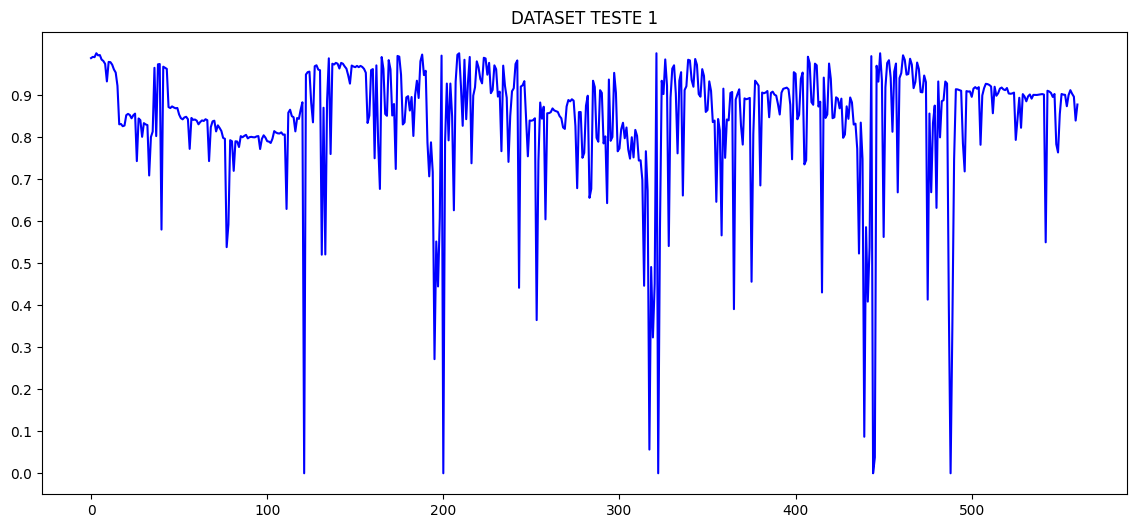

In [57]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_4, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

X shape (531, 1)
y shape (531, 30)


c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.6552 - val_loss: 0.1796
Epoch 2/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1868 - val_loss: 0.1588
Epoch 3/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1656 - val_loss: 0.1677
Epoch 4/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1601 - val_loss: 0.0674
Epoch 5/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1437 - val_loss: 0.0663
Epoch 6/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1374 - val_loss: 0.1381
Epoch 7/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1394 - val_loss: 0.0978
Epoch 8/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1329 - val_loss: 0.0924
Epoch 9/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1300 - val_loss: 0.1046
Epoch 10/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1248 - val_loss: 0.1066
Epoch 11/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1281 - val_loss: 0.1077


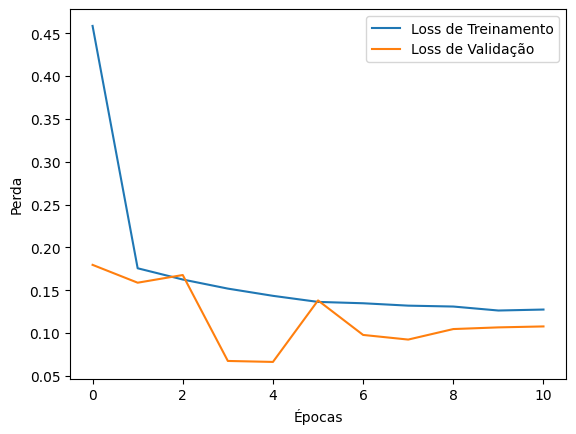

Epoch 1/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1310 - val_loss: 0.1144
Epoch 2/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1224 - val_loss: 0.1198
Epoch 3/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1219 - val_loss: 0.1281
Epoch 4/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1203 - val_loss: 0.1257
Epoch 5/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1177 - val_loss: 0.1267
Epoch 6/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1153 - val_loss: 0.1317


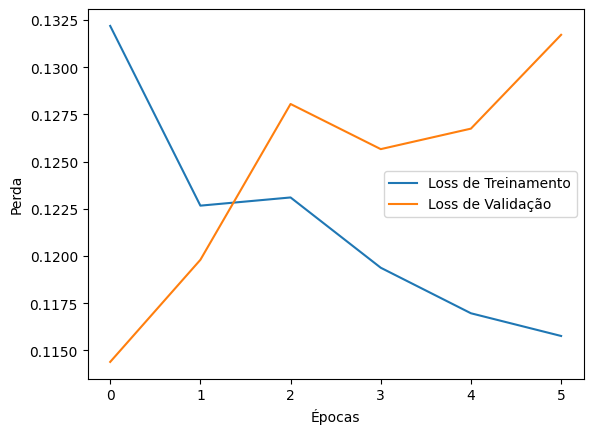

Epoch 1/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1238 - val_loss: 0.1273
Epoch 2/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1225 - val_loss: 0.1437
Epoch 3/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1217 - val_loss: 0.1211
Epoch 4/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1168 - val_loss: 0.1199
Epoch 5/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1146 - val_loss: 0.1489
Epoch 6/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1144 - val_loss: 0.1367


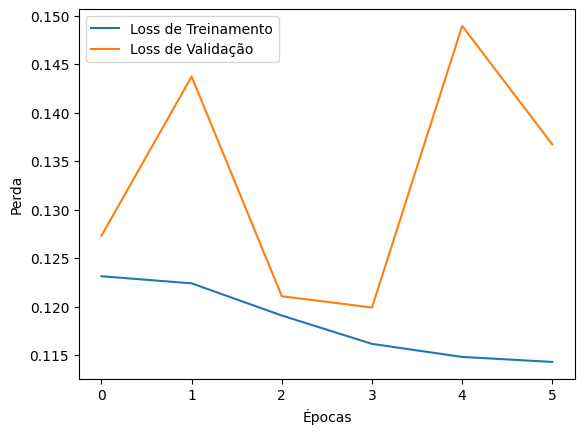

Epoch 1/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1248 - val_loss: 0.0963
Epoch 2/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1224 - val_loss: 0.0991
Epoch 3/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1234 - val_loss: 0.0993
Epoch 4/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1187 - val_loss: 0.0946
Epoch 5/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1183 - val_loss: 0.0970
Epoch 6/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1172 - val_loss: 0.0940


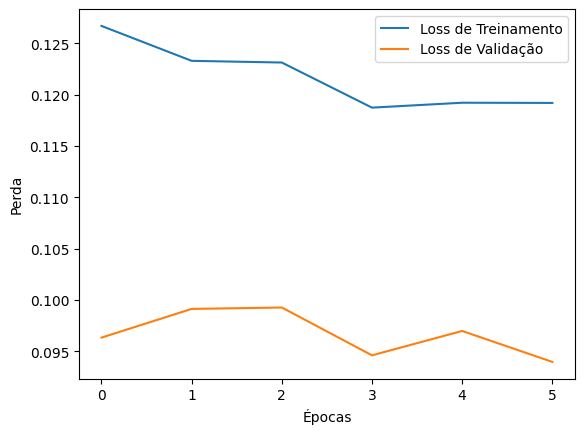

Epoch 1/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1195 - val_loss: 0.1054
Epoch 2/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1175 - val_loss: 0.0988
Epoch 3/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1168 - val_loss: 0.1001
Epoch 4/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1137 - val_loss: 0.1007
Epoch 5/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1097 - val_loss: 0.1001
Epoch 6/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1140 - val_loss: 0.0992


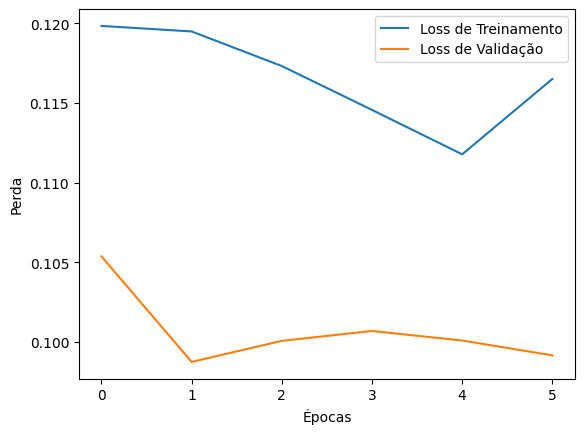

In [58]:
timesteps = config['datasets'][dataset_type]["timesteps"]
output_steps = config['datasets'][dataset_type]["output_horizon"]
X, y = create_dataset(dataset_test_4, timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("X_train shape", np.array(X_train).shape)
# print("y_train shape", np.array(y_train).shape)
# print("X_test shape", np.array(X_test).shape)
# print("y_test shape", np.array(y_test).shape)

model_4 = create_model(config, dataset_type, X, y, 5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step


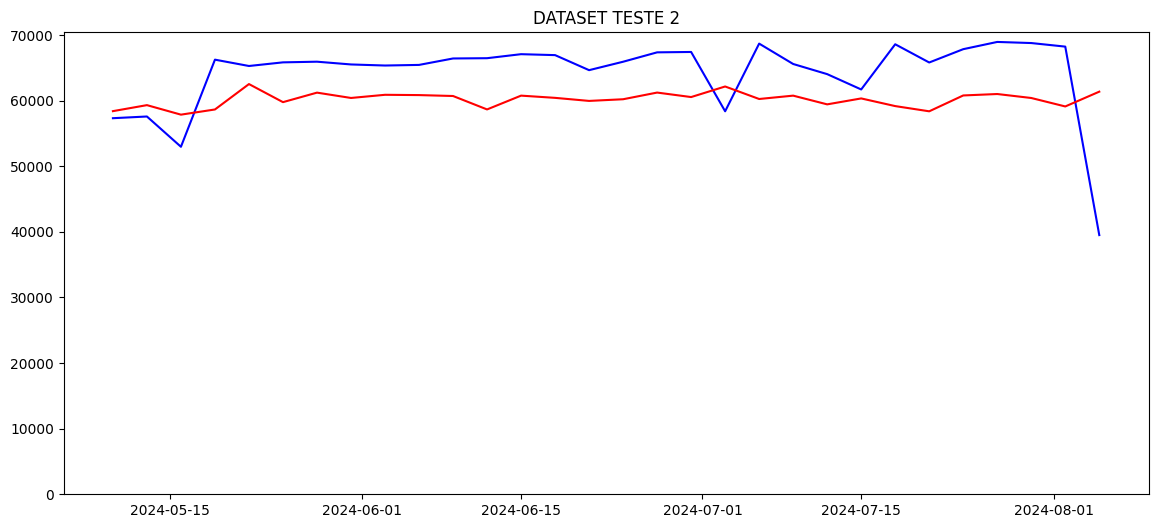

In [59]:
pred = model_4.predict(duas_unas_validation_scaled.iloc[0])
y_pred_rescaled = scalers[4].inverse_transform(pred)
y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("DATASET TESTE 2")
plt.show()

In [60]:
avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

[57325.32 57584.52 52969.32 66248.64 65283.48 65837.16 65937.96 65518.2
 65354.76 65447.64 66429.72 66471.48 67083.12 66940.2  64648.08 65931.48
 67363.2  67420.8  58378.32 68695.2  65588.4  64043.28 61705.8  68594.76
 65816.64 67846.32 68950.08 68780.88 68236.2  39506.76]
 
[58400.414 59316.645 57865.547 58655.867 62527.586 59772.145 61221.895
 60409.71  60891.89  60847.703 60708.58  58661.004 60765.8   60426.258
 59960.09  60213.863 61232.234 60547.703 62158.957 60252.816 60764.094
 59434.016 60338.945 59171.297 58375.887 60792.105 61011.023 60405.66
 59115.574 61370.09 ]
 
MAE(Erro absoluto médio) Score of LSTM model =  6233.905
 
MSE(Erro quadrático médio) Score of LSTM model =  51846391.307
 
RMSE(Raiz do erro quadrático médio) Score of LSTM model =  7200.444
 
MAPE(Erro percentual médio absoluto) Score of LSTM model =  0.1
 
2% Accuracy Score of LSTM model =  3.33
5% Accuracy Score of LSTM model =  13.33
10% Accuracy Score of LSTM model =  63.33


(6233.9, 51846391.31, 7200.44, 0.1, 3.33, 13.33, 63.33)

In [61]:
acumulado_1mes_real = duas_unas_validation_rescaled[:10].sum()
acumulado_2mes_real = duas_unas_validation_rescaled[:20].sum()
acumulado_3mes_real = duas_unas_validation_rescaled[:30].sum()

acumulado_1mes_pred = y_pred_rescaled[:10].sum()
acumulado_2mes_pred = y_pred_rescaled[:20].sum()
acumulado_3mes_pred = y_pred_rescaled[:30].sum()

print("Erro percentual acumulado 30 dias:", round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2),"%")
print("Erro percentual acumulado 60 dias:", round(((abs(acumulado_2mes_real-acumulado_2mes_pred))/acumulado_2mes_real)*100, 2),"%")
print("Erro percentual acumulado 90 dias:", round(((abs(acumulado_3mes_real-acumulado_3mes_pred))/acumulado_3mes_real)*100, 2),"%")


Erro percentual acumulado 30 dias: 4.4 %
Erro percentual acumulado 60 dias: 6.37 %
Erro percentual acumulado 90 dias: 6.25 %
